# Lab:  Nonlinear Least Squares for Modeling Materials

Nonlinear least squares (NLLS) is a widely-used method for modeling data.  In NLLS, we wish to fit a model of the form,

     yhat = g(x,w)
     
where `w` is a vector of paramters and `x` is the vector of predictors.  We find `w` by minimizing a least-squares function 

     f(w) = \sum_i (y_i - g(x_i,w))^2
     
where the summation is over training samples `(x_i,y_i)`.  This is similar to linear least-squares, but the function `g(x,w)` may not be linear in `w`.  In general, this optimization has no closed-form expression.  So numerical optimization must be used.  

In this lab, we will implement gradient descent on NLLS in a problem of physical modeling of materials.  Specifically, we will estimate parameters for expansion of copper as a function of temperature using a real dataset.  In doing this lab, you will learn to:
* Set up a nonlinear least squares as an unconstrained optimization function
* Compute initial parameter estimates for a simple rational model
* Compute the gradients of the least squares objective
* Implement gradient descent for minimizing the objective
* Implement momentum gradient descent
* Visualize the convergence of the algorithm

We first import some key packages.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression

## Load the Data

The NIST agency has an excellent [nonlinear regression website](https://www.itl.nist.gov/div898/strd/nls/nls_main.shtml) that has several datasets for nonlinear regression problems.  In this lab, we will use the data from a NIST study involving the thermal expansion of copper. The response variable is the coefficient of thermal expansion, and the predictor variable is temperature in degrees kelvin.  

> Hahn, T., NIST (1979), Copper Thermal Expansion Study.  (unpublished}

You can download the data as follows.

In [99]:
import pandas as pd

df = pd.read_csv('Hahn1.dat', skiprows=60, sep=r'\s+', names=['y0', 'x0'])
df.head()

,y0,x0
0,0.591,24.41
1,1.547,34.82
2,2.902,44.09
3,2.894,45.07
4,4.703,54.98


Extract the `x0` and `y0` into arrays.  Rescale, `x0` and `y0` to values between `0` and `1` by dividing `x0` and `y0` by the maximum value.  Store the scaled values in vectors `x` and `y`.  The rescaling will help with the conditioning of the fitting.  Plot, `y` vs. `x`. 

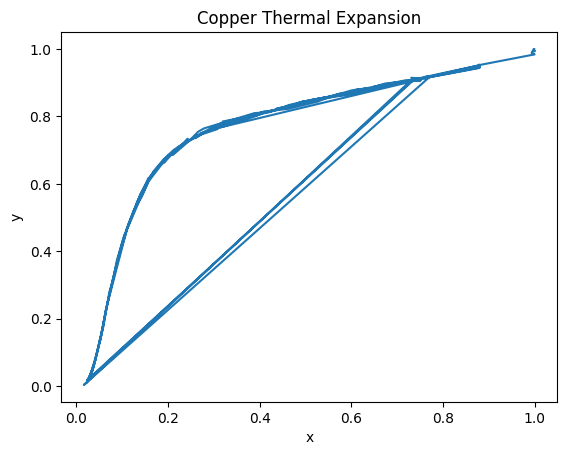

In [100]:
# TODO
x0 = df['x0']
y0 = df['y0']
x = x0/np.max(x0)
y = y0/np.max(y0)
plt.plot(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Copper Thermal Expansion')
plt.show()


To make the problem a little more challenging, we will add some noise.  Add random Gaussian noise with mean 0 and std. dev = 0.02 to `y`.  Store the noisy results in `yn`. You can use the `np.random.normal()` function to add Gaussian noise. Plot `yn` vs. `x`.

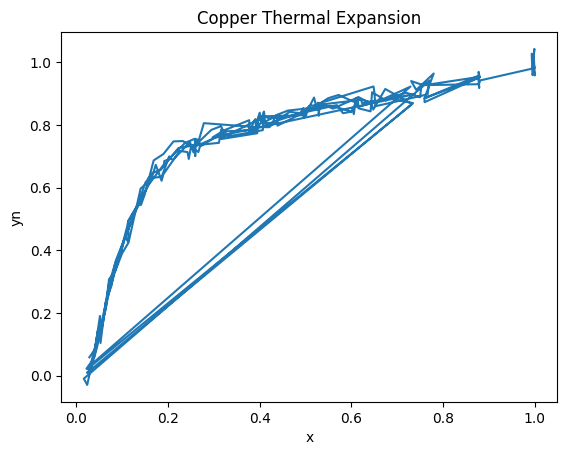

In [101]:
# TODO
yn = y + np.random.normal(0,0.02,len(y))
plt.plot(x,yn)
plt.xlabel('x')
plt.ylabel('yn')
plt.title('Copper Thermal Expansion')
plt.show()

Split the data `(x,yn)` into training and test.  Let `xtr,ytr` be training data and `xts,yts` be the test data.  You can use the `train_test_split` function.  Set `test_size=0.33` so that 1/3 of the samples are held out for test.

In [102]:
from sklearn.model_selection import train_test_split

# TODO
xtr, xts, ytr, yts = train_test_split(x, yn, test_size=0.33, random_state=42)

## Initial Fit for a Rational Model

The [NIST website](https://www.itl.nist.gov/div898/strd/nls/data/hahn1.shtml) suggests using a *rational* model of the form,

      yhat = (a[0] + a[1]*x + ... + a[d]*x^d)/(1 + b[0]*x + ... + b[d-1]*x^d)
      
with `d=3`.  The model parameters are `w = [a[0],...,a[d],b[0],...,b[d-1]]` so there are `2d+1` parameters total.    Complete the function below that takes vectors `w` and `x` and predicts a set of values `yhat` using the above model.
   

In [105]:
def predict(w,x):
    
    # Get the length
    d = (len(w)-1)//2
    
    # TODO.  Extract a and b from w
    a = w[0:d+1]
    b = w[d+1:2*d+1]

    print(a)
    print(b)
    
    # TODO.  Compute yhat.  You may use the np.polyval function
    # But, remember you must flip the order the a and b
    # Also need to handle the case where b might be shorter
    if len(b) < d:
        # Pad b with zeros if needed
        b_padded = np.zeros(d)
        b_padded[:len(b)] = b
        b = b_padded
    
    yhat = np.polyval(a[::-1],x) / (1 + np.polyval(b[::-1],x))
    return yhat


When we fit with a nonlinear model, most methods only get convergence to a local minima.  So, you need a good initial condition.  For a rational model, one way to get is to realize that if:


    y ~= (a[0] + a[1]*x + ... + a[d]*x^d)/(1 + b[0]*x + ... + b[d-1]*x^d)
    
Then:

    y ~= a[0] + a[1]*x + ... + a[d]*x^d - b[0]*x*y + ... - b[d-1]*x^d*y.
    
So, we can solve for the the parameters `w = [a,b]` from linear regression of the predictors,

    Z[i,:] = [ x[i], ... , x[i]**d, y[i]*x[i], ... , y[i}*x[i]**d ] 

In [106]:
d = 3

# Create the transformed feature matrix
# Z[i,:] = [ x[i], ... , x[i]**d, y[i]*x[i], ... , y[i]*x[i]**d ]
n = len(xtr)
Z = np.zeros((n, 2*d+1))
for i in range(n):
    # First d+1 columns: powers of x from x^0 to x^d
    for j in range(d+1):
        Z[i,j] = xtr.iloc[i]**j
    # Next d columns: y*x^j for j=1 to d
    for j in range(d):
        Z[i,d+1+j] = ytr.iloc[i]*xtr.iloc[i]**(j+1)

# Fit with parameters with linear regression
regr = LinearRegression()
regr.fit(Z, ytr)

# Extract the parameters from regr.coef_ and regr.intercept_ and store the parameter vector in winit
winit = np.concatenate([regr.intercept_.reshape(1), regr.coef_])

Now plot the predicted values of the `yhat` vs. `x` using your estimated parameter `winit` for 1000 values `x` in `[0,1]`.  On the same plot, plot `yts` vs. `xts`.  You will see that you get a horrible fit.

[ -0.26576416   0.          11.30788577 -35.53285547]
[26.22091421 -5.75041422 28.16235939]


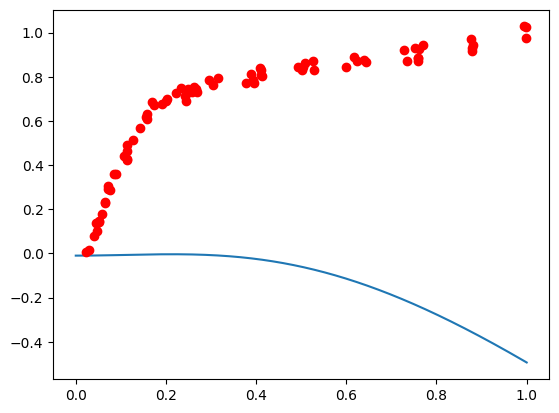

In [107]:
# TODO
xp = np.linspace(0,1,1000)
yhat = predict(winit,xp)
plt.plot(xp,yhat)
plt.plot(xts,yts,'ro')
plt.show()

The reason the previous fit is poor is that the denominator in `yhat` goes close to zero.   To avoid this problem, we can use Ridge regression, to try to keep the parameters close to zero.  Re-run the fit above with `Ridge` with `alpha = 1e-3`. You should see you get a reasonable, but not perfect fit.

[-0.0184798   0.          4.45483683 -6.69706987]
[ 2.46012147 -0.00410943 -0.51849687]


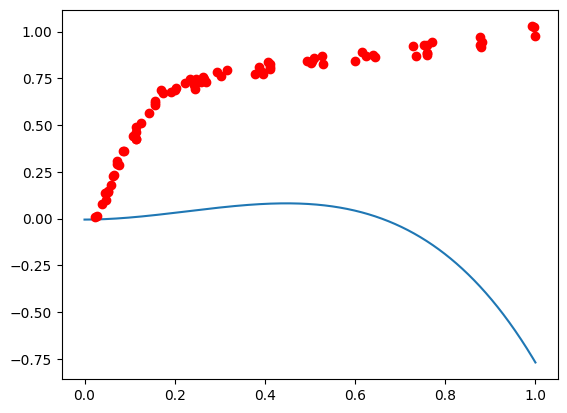

In [108]:
# TODO.  Fit with parameters with linear regression
regr = Ridge(alpha=1e-3)
regr.fit(Z, ytr)

# TODO
# Extract the parameters from regr.coef_ and regr.intercept_
winit = np.concatenate((regr.intercept_.reshape(1), regr.coef_))

# TODO
# Plot the results as above.
xp = np.linspace(0,1,1000)
yhat = predict(winit,xp)
plt.plot(xp,yhat)
plt.plot(xts,yts,'ro')
plt.show()


## Creating a Loss Function

We can now use gradient descent to improve our initial estimate.  Complete the following function to compute

    f(w) = 0.5*\sum_i (y[i] - yhat[i])^2
    
and `fgrad`, the gradient of `f(w)`.

In [111]:
def feval(w,x,y):
    
    # Parse w
    a = w[0:d+1]
    b = w[d+1:2*d+1]
    
    # Znum[i,j] = x[i]**j
    Znum = np.zeros((len(x),d+1))
    for i in range(len(x)):
        for j in range(d+1):
            Znum[i,j] = x.iloc[i]**j

    # Zden[i,j] = x[i]**(j+1) for j=0 to d-1
    Zden = np.zeros((len(x),d))
    for i in range(len(x)):
        for j in range(d):
            Zden[i,j] = x.iloc[i]**(j+1)
    
    # Compute yhat 
    numerator = np.sum(a*Znum, axis=1)
    denominator = 1 + np.sum(b*Zden, axis=1)
    yhat = numerator / denominator
    
    # Compute loss
    f = 0.5*np.sum((y-yhat)**2)
    
    # Compute gradients - FIXED VERSION
    residual = y - yhat
    
    # Gradient with respect to a (numerator coefficients)
    grad_a = np.zeros(d+1)
    for j in range(d+1):
        grad_a[j] = -np.sum(residual * Znum[:,j] / denominator)
    
    # Gradient with respect to b (denominator coefficients)  
    grad_b = np.zeros(d)
    for j in range(d):
        grad_b[j] = np.sum(residual * numerator * Zden[:,j] / (denominator**2))
    
    # Combine gradients
    fgrad = np.concatenate([grad_a, grad_b])
    
    return f, fgrad

Test the gradient function:
* Take `w0=winit` and compute `f0,fgrad0 = feval(w0,xtr,ytr)`
* Take `w1` very close to `w0` and compute `f1,fgrad1 = feval(w1,xtr,ytr)`
* Verify that `f1-f0` is close to the predicted value based on the gradient.

In [113]:
# TODO
w0 = winit[1:].copy()  # Skip intercept, use only the 7 coefficients
w1 = w0 + 1e-6*np.random.randn(len(w0))
f0,fgrad0 = feval(w0,xtr,ytr)
f1,fgrad1 = feval(w1,xtr,ytr)
print(f1-f0)
print(np.sum(fgrad0*(w1-w0)))

-2.1779041681213585e-07
-2.1789167796896085e-07


## Implement gradient descent

We will now try to minimize the loss function with gradient descent.  Using the function `feval` defined above, implement gradient descent.  Run gradient descent with a step size of `alpha=1e-6` starting at `w=winit`.  Run it for `nit=10000` iterations.  Compute `fgd[it]`= the objective function on iteration `it`.  Plot `fgd[it]` vs. `it`.  

You should see that the training loss decreases, but it still hasn't converged after 10000 iterations.

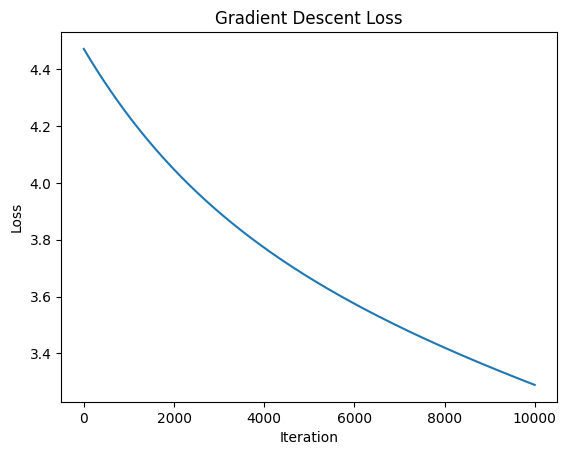

In [114]:
# TODO run gradient descent

nit = 10000
step = 1e-6
fgd = np.zeros(nit)

# Use only the 7 coefficients (skip intercept)
w = winit[1:].copy()

for it in range(nit):
    f,fgrad = feval(w,xtr,ytr)
    w = w - step*fgrad
    fgd[it] = f

# plot fgd[it] vs. it
plt.plot(fgd)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Gradient Descent Loss')
plt.show()


Now, try to get a faster convergence with adaptive step-size using the Armijo rule. Implement the gradient descent with adaptive step size.  Let `fadapt[it]` be the loss function on iteration `it`.  Plot `fadapt[it]` and `fgd[it]` vs. `it` on the same graph.  You should see a slight improvement, but not much.

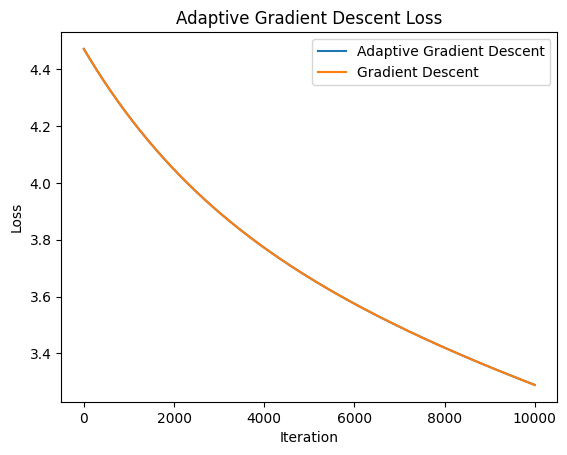

In [115]:
# TODO
nit = 10000
step = 1e-6  # Initial step
fadapt = np.zeros(nit)

# Initialize w for adaptive GD - use only the 7 coefficients (skip intercept)
w_adapt = winit[1:].copy()

for it in range(nit):
    f, fgrad = feval(w_adapt, xtr, ytr)
    
    # Armijo rule: find step size that satisfies sufficient decrease condition
    alpha = step
    c1 = 1e-4  # Armijo parameter
    max_backtrack = 20
    
    for backtrack in range(max_backtrack):
        w_new = w_adapt - alpha * fgrad
        f_new, _ = feval(w_new, xtr, ytr)
        
        # Armijo condition: f(w - α∇f) ≤ f(w) - c₁α||∇f||²
        armijo_condition = f_new <= f - c1 * alpha * np.sum(fgrad**2)
        
        if armijo_condition:
            break
        else:
            alpha *= 0.5  # Reduce step size
    
    w_adapt = w_adapt - alpha * fgrad
    fadapt[it] = f

# plot fadapt[it] vs. it
plt.plot(fadapt)
plt.plot(fgd)
plt.legend(['Adaptive Gradient Descent', 'Gradient Descent'])
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Adaptive Gradient Descent Loss')
plt.show()

Using he final estimate for w from the adaptive step-size plot the predicted values of the yhat vs. x usfor 1000 values x in [0,1]. On the same plot, plot yhat vs. x for the initial parameter w=winit. Also, plot yts vs. xts. You should see that gradient descent was able to improve the estimat slightly, although the initial estimate was not too bad.



[ 0.03027063  4.51260135 -6.64168774  2.51009198]
[-0.02125606 -0.53695614  1.36457907]
[ 0.          4.45483683 -6.69706987  2.46012147]
[-0.00410943 -0.51849687  1.38115586]


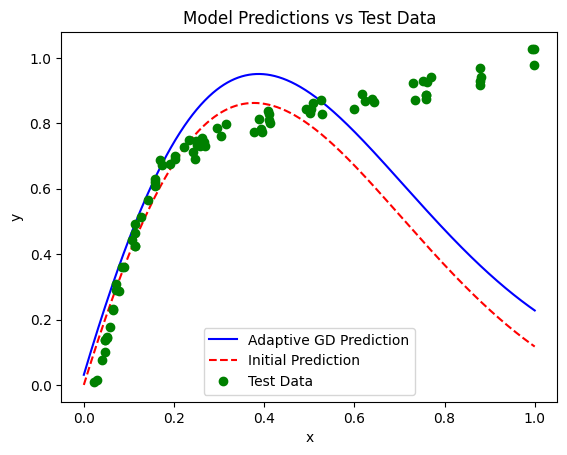

In [116]:
# Generate x values for plotting
x_plot = np.linspace(0, 1, 1000)

# Calculate predictions using final adaptive GD weights
yhat_adapt = predict(w_adapt, x_plot)

# Calculate predictions using initial weights (use only the 7 coefficients)
yhat_init = predict(winit[1:], x_plot)

# Plot predictions and test data
plt.figure()
plt.plot(x_plot, yhat_adapt, 'b-', label='Adaptive GD Prediction')
plt.plot(x_plot, yhat_init, 'r--', label='Initial Prediction')
plt.plot(xts, yts, 'go', label='Test Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model Predictions vs Test Data')
plt.legend()
plt.show()

## Momentum Gradient Descent

This section is bonus.

One way to improve gradient descent is to use *momentum*.  In momentum gradient descent, the update rule is:

    f, fgrad = feval(w,...)
    z = beta*z + fgrad
    w = w - step*z
    
This is similar to gradient descent, except that there is a second order term on the gradient.  Implement this algorithm with `beta = 0.99` and `step=1e-3`.   Compare the convergence of the loss function with gradient descent.  

In [117]:
# TODO
nit = 1000
step = 1e-3
beta = 0.99

In [118]:
# TODO
# plot yhat vs. x

## Beyond This Lab
In this lab, we have just touched at some of the ideas in optimization.  There are several other important algorithms that you can explore:
* [Levenberg-Marquardt](https://en.wikipedia.org/wiki/Levenberg%E2%80%93Marquardt_algorithm) method for non-linear least squares
* Newton's method
* More difficult non-linear least squares problems.